In [1]:
# ============================================================
# STEP 1: Upload & Load Dataset
# ============================================================
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("=== Shape ===", df.shape)
print("\n=== Columns ===")
print(df.columns.tolist())
print("\n=== First 3 Rows ===")
print(df.head(3))
print("\n=== Missing Values ===")
print(df.isnull().sum())

Saving 3) Sentiment dataset.csv to 3) Sentiment dataset.csv
=== Shape === (732, 15)

=== Columns ===
['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

=== First 3 Rows ===
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    

                                     Hashtags  Retweets  Likes       Country  \
0   #Nature #

In [2]:
# ============================================================
# STEP 2: Preprocess the Data
# ============================================================

# --- Clean column whitespace ---
df['Sentiment'] = df['Sentiment'].str.strip()
df['Platform']  = df['Platform'].str.strip()
df['Country']   = df['Country'].str.strip()

# --- Group 279 raw sentiment labels into 3 clean classes ---
def map_sentiment(s):
    positive_words = ['Positive', 'Joy', 'Happiness', 'Excitement', 'Love',
                      'Contentment', 'Happy', 'Relief', 'Amusement', 'Mischievous']
    negative_words = ['Negative', 'Anger', 'Fear', 'Sadness', 'Disgust',
                      'Hate', 'Bad', 'Sad', 'Boredom', 'Embarrassed', 'Indifference']
    if s in positive_words:
        return 'Positive'
    elif s in negative_words:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment_label'] = df['Sentiment'].apply(map_sentiment)

print("=== Sentiment Class Distribution ===")
print(df['Sentiment_label'].value_counts())

# --- Select numerical features for KNN ---
feature_cols = ['Retweets', 'Likes', 'Year', 'Month', 'Day', 'Hour']
X_raw = df[feature_cols].copy()
y_raw = df['Sentiment_label'].copy()

# --- Handle any remaining missing values ---
X_raw.fillna(X_raw.mean(), inplace=True)

print("\n=== Features Selected ===")
print(feature_cols)
print("\n=== Feature Sample ===")
print(X_raw.head(5))


=== Sentiment Class Distribution ===
Sentiment_label
Neutral     505
Positive    173
Negative     54
Name: count, dtype: int64

=== Features Selected ===
['Retweets', 'Likes', 'Year', 'Month', 'Day', 'Hour']

=== Feature Sample ===
   Retweets  Likes  Year  Month  Day  Hour
0      15.0   30.0  2023      1   15    12
1       5.0   10.0  2023      1   15     8
2      20.0   40.0  2023      1   15    15
3       8.0   15.0  2023      1   15    18
4      12.0   25.0  2023      1   15    19


In [3]:
# ============================================================
# STEP 3: Encode Target & Scale Features
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# --- Label Encode target ---
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("=== Label Encoding ===")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

# --- Standardize features (CRITICAL for KNN — distance-based!) ---
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("\n=== Feature Scaling Done (StandardScaler) ===")

# --- Train / Test Split (80% / 20%, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Class distribution (train): {dict(zip(le.classes_, np.bincount(y_train)))}")

=== Label Encoding ===
  Negative → 0
  Neutral → 1
  Positive → 2

=== Feature Scaling Done (StandardScaler) ===

Training samples : 585
Testing samples  : 147
Class distribution (train): {'Negative': np.int64(43), 'Neutral': np.int64(404), 'Positive': np.int64(138)}


       KNN Results — K = 5
  Accuracy : 72.11%

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.33      0.27      0.30        11
     Neutral       0.81      0.86      0.83       101
    Positive       0.53      0.46      0.49        35

    accuracy                           0.72       147
   macro avg       0.56      0.53      0.54       147
weighted avg       0.71      0.72      0.71       147



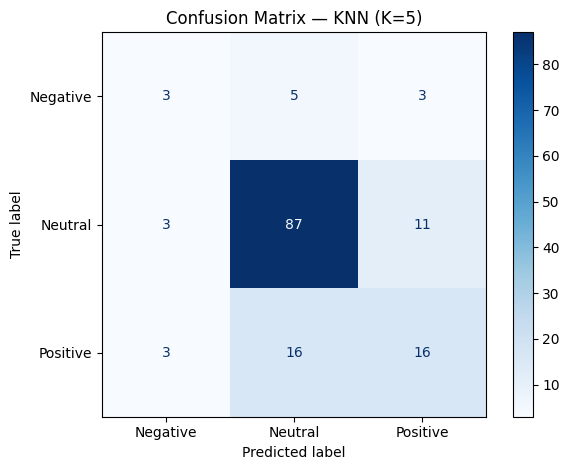

✅ Confusion matrix saved!


In [4]:
# ============================================================
# STEP 4: Train KNN Classifier (K = 5)
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# --- Train with K=5 ---
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train, y_train)

y_pred_5 = knn_5.predict(X_test)

print("=" * 45)
print("       KNN Results — K = 5")
print("=" * 45)
print(f"  Accuracy : {accuracy_score(y_test, y_pred_5)*100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_5, target_names=le.classes_))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_5)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — KNN (K=5)')
plt.tight_layout()
plt.savefig('confusion_matrix_k5.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

In [5]:
# ============================================================
# STEP 5: Compare Different K Values (1, 3, 5, 7, 9, 11, 15)
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score

k_values   = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies = []
precisions = []
recalls    = []
f1_scores  = []

print(f"{'K':>4} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>8} | {'F1-Score':>9}")
print("-" * 55)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1)

    print(f"{k:>4} | {acc*100:>9.2f}% | {prec*100:>9.2f}% | {rec*100:>7.2f}% | {f1*100:>8.2f}%")

best_k   = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\n🏆 Best K = {best_k}  →  Accuracy = {best_acc*100:.2f}%")

   K |   Accuracy |  Precision |   Recall |  F1-Score
-------------------------------------------------------
   1 |     68.03% |     67.54% |   68.03% |    67.70%
   3 |     69.39% |     69.47% |   69.39% |    69.36%
   5 |     72.11% |     70.54% |   72.11% |    71.17%
   7 |     72.11% |     69.12% |   72.11% |    70.13%
   9 |     75.51% |     73.67% |   75.51% |    74.23%
  11 |     76.87% |     75.05% |   76.87% |    75.67%
  15 |     74.83% |     72.56% |   74.83% |    73.07%
  21 |     75.51% |     71.53% |   75.51% |    72.12%

🏆 Best K = 11  →  Accuracy = 76.87%


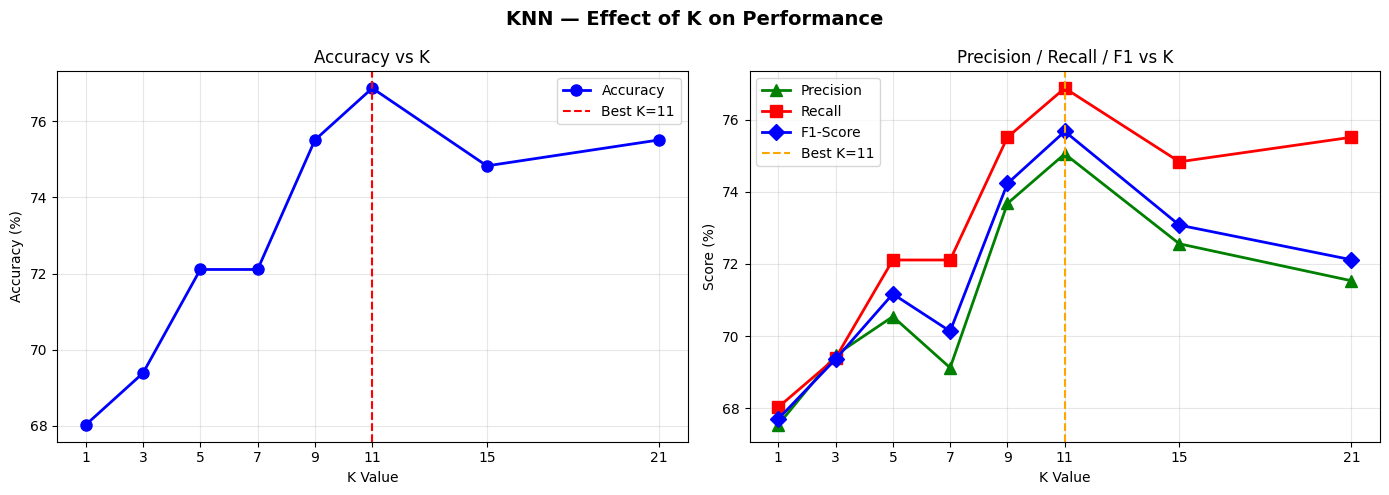

✅ K comparison plot saved!


In [6]:
# ============================================================
# STEP 6: Visualize K Value Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KNN — Effect of K on Performance', fontsize=14, fontweight='bold')

# --- Plot 1: Accuracy vs K ---
axes[0].plot(k_values, [a*100 for a in accuracies], 'bo-', linewidth=2, markersize=8, label='Accuracy')
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[0].set_xlabel('K Value')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy vs K')
axes[0].set_xticks(k_values)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Precision / Recall / F1 vs K ---
axes[1].plot(k_values, [p*100 for p in precisions], 'g^-', linewidth=2, markersize=8, label='Precision')
axes[1].plot(k_values, [r*100 for r in recalls],    'rs-', linewidth=2, markersize=8, label='Recall')
axes[1].plot(k_values, [f*100 for f in f1_scores],  'bD-', linewidth=2, markersize=8, label='F1-Score')
axes[1].axvline(x=best_k, color='orange', linestyle='--', label=f'Best K={best_k}')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Score (%)')
axes[1].set_title('Precision / Recall / F1 vs K')
axes[1].set_xticks(k_values)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_k_comparison.png', dpi=150)
plt.show()
print("✅ K comparison plot saved!")

Training final KNN model with best K = 11 ...

   FINAL MODEL — KNN (K = 11)
  Accuracy  : 76.87%
  Precision : 75.05%
  Recall    : 76.87%
  F1-Score  : 75.67%

=== Per-Class Classification Report ===
              precision    recall  f1-score   support

    Negative       0.38      0.27      0.32        11
     Neutral       0.84      0.91      0.87       101
    Positive       0.62      0.51      0.56        35

    accuracy                           0.77       147
   macro avg       0.61      0.57      0.58       147
weighted avg       0.75      0.77      0.76       147



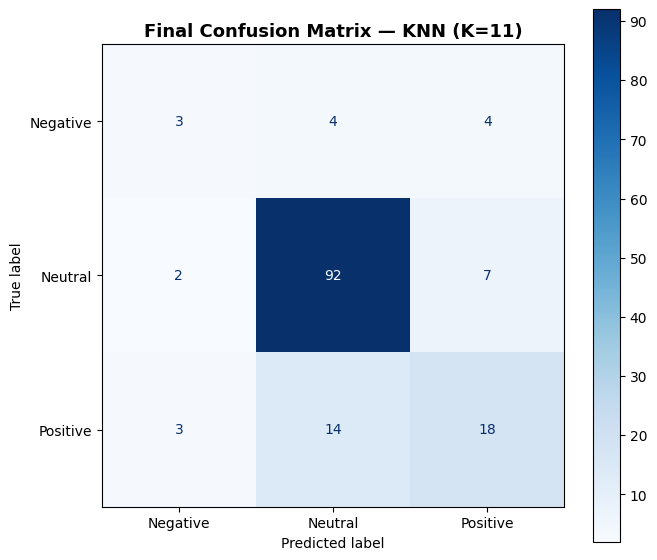

✅ Final confusion matrix saved!


In [7]:
# ============================================================
# STEP 7: Train Best Model & Detailed Evaluation
# ============================================================

print(f"Training final KNN model with best K = {best_k} ...")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

print("\n" + "=" * 50)
print(f"   FINAL MODEL — KNN (K = {best_k})")
print("=" * 50)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_best)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred_best, average='weighted', zero_division=0)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, y_pred_best, average='weighted', zero_division=0)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_test, y_pred_best, average='weighted', zero_division=0)*100:.2f}%")
print("=" * 50)

print("\n=== Per-Class Classification Report ===")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# --- Final Confusion Matrix ---
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp_best.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Final Confusion Matrix — KNN (K={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150)
plt.show()
print("✅ Final confusion matrix saved!")

In [8]:
# ============================================================
# STEP 8: Final Summary
# ============================================================

print("=" * 55)
print("        TASK 3 COMPLETE — FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset          : Social Media Sentiment (732 rows)")
print(f"  Features used    : Retweets, Likes, Year, Month, Day, Hour")
print(f"  Target classes   : {list(le.classes_)}")
print(f"  Scaling          : StandardScaler (required for KNN)")
print(f"  Train/Test split : 80% / 20%")
print(f"  K values tested  : {k_values}")
print("-" * 55)
print(f"  Best K           : {best_k}")
print(f"  Best Accuracy    : {best_acc*100:.2f}%")
print("=" * 55)
print("\n📌 Key Insight:")
print("   KNN is a distance-based algorithm — scaling features")
print("   with StandardScaler is ESSENTIAL for good performance.")
print("   Higher K = smoother boundary but may underfit.")
print("   Lower K = sensitive to noise but may overfit.")
print("\n✅ Model is ready!")

        TASK 3 COMPLETE — FINAL SUMMARY
  Dataset          : Social Media Sentiment (732 rows)
  Features used    : Retweets, Likes, Year, Month, Day, Hour
  Target classes   : ['Negative', 'Neutral', 'Positive']
  Scaling          : StandardScaler (required for KNN)
  Train/Test split : 80% / 20%
  K values tested  : [1, 3, 5, 7, 9, 11, 15, 21]
-------------------------------------------------------
  Best K           : 11
  Best Accuracy    : 76.87%

📌 Key Insight:
   KNN is a distance-based algorithm — scaling features
   with StandardScaler is ESSENTIAL for good performance.
   Higher K = smoother boundary but may underfit.
   Lower K = sensitive to noise but may overfit.

✅ Model is ready!
